<a href="https://colab.research.google.com/github/arpitm1037/customer-lifetime-proxy-ml/blob/main/CustomerLifeTimeProxy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

#CONFIG
BUCKET_LABELS = ["Low", "Medium", "High", "VIP"]

#LOAD DATA
df = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")
df.head()

#DATA CLEANING
df = df.dropna(subset=["CustomerID"])
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df["CustomerID"] = df["CustomerID"].astype(int)

df.head()

Saving online_retail.csv to online_retail.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


Shape: (397884, 9)


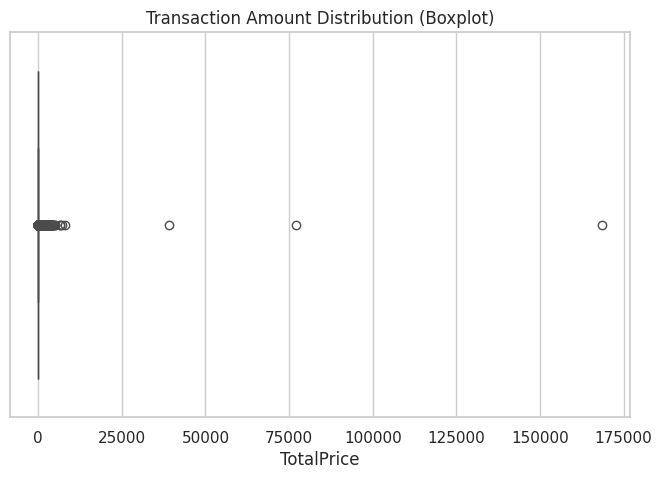

In [ ]:
#EDA
print("Shape:", df.shape)
df.describe()

plt.figure(figsize=(8,5))
sns.boxplot(x=df["TotalPrice"])
plt.title("Transaction Amount Distribution (Boxplot)")
plt.show()

In [ ]:
#FEATURE ENGINEERING

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

def calculate_recency(x):
    return (snapshot_date - x.max()).days

def calculate_frequency(x):
    return x.count()

def calculate_monetary(x):
    return x.sum()

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": [calculate_recency, calculate_frequency],
    "TotalPrice": calculate_monetary
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm = rfm.reset_index()

# Tenure
first_purchase = df.groupby("CustomerID")["InvoiceDate"].min()
rfm["Tenure"] = rfm["CustomerID"].map(
    lambda cid: (snapshot_date - first_purchase[cid]).days
)

# Trend
monthly = (
    df.set_index("InvoiceDate")
    .groupby("CustomerID")["TotalPrice"]
    .resample("ME")
    .sum()
    .reset_index()
)

trend = monthly.groupby("CustomerID")["TotalPrice"].apply(
    lambda x: x.diff().mean()
)

rfm["Trend"] = rfm["CustomerID"].map(trend).fillna(0)

rfm.head()


,CustomerID,Recency,Frequency,Monetary,Tenure,Trend
0,12346,326,1,77183.60,326,0.000000
1,12347,2,182,4310.00,367,-40.580833
2,12348,75,31,1797.24,358,-64.755556
3,12349,19,73,1757.55,19,0.000000
4,12350,310,17,334.40,310,0.000000


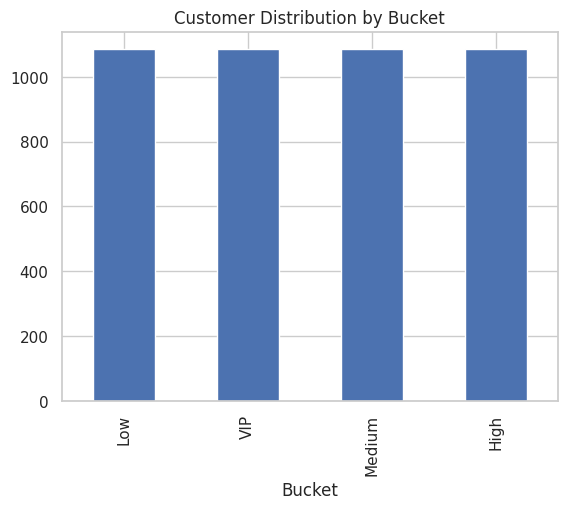

In [ ]:
#LABEL GENERATION
cutoff_date = df["InvoiceDate"].max() - pd.DateOffset(months=6)

future = df[df["InvoiceDate"] > cutoff_date]

future_spend = future.groupby("CustomerID")["TotalPrice"].sum()

rfm["FutureSpend"] = rfm["CustomerID"].map(future_spend).fillna(0)

rfm["Bucket"] = pd.qcut(
    rfm["FutureSpend"],
    q=4,
    labels=BUCKET_LABELS
)

dataset = rfm.copy()

dataset.head()

#Bucket Distribution
dataset["Bucket"].value_counts().plot(kind="bar")
plt.title("Customer Distribution by Bucket")
plt.show()

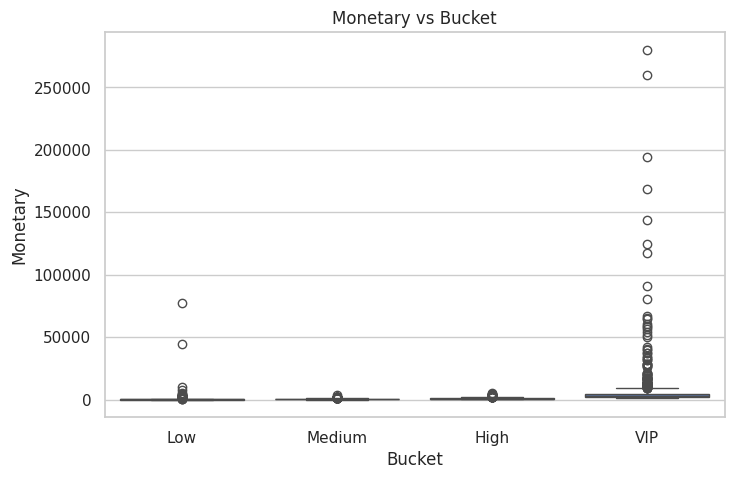

In [ ]:
#FEATURE VALIDATION

plt.figure(figsize=(8,5))
sns.boxplot(x="Bucket", y="Monetary", data=dataset)
plt.title("Monetary vs Bucket")
plt.show()


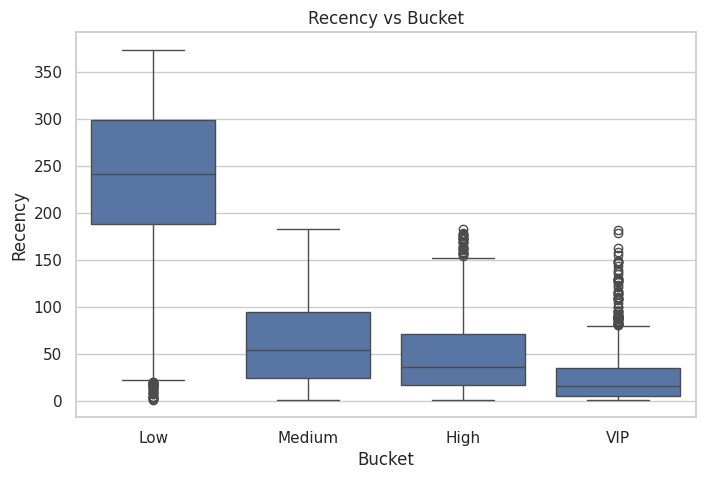

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Bucket", y="Recency", data=dataset)
plt.title("Recency vs Bucket")
plt.show()

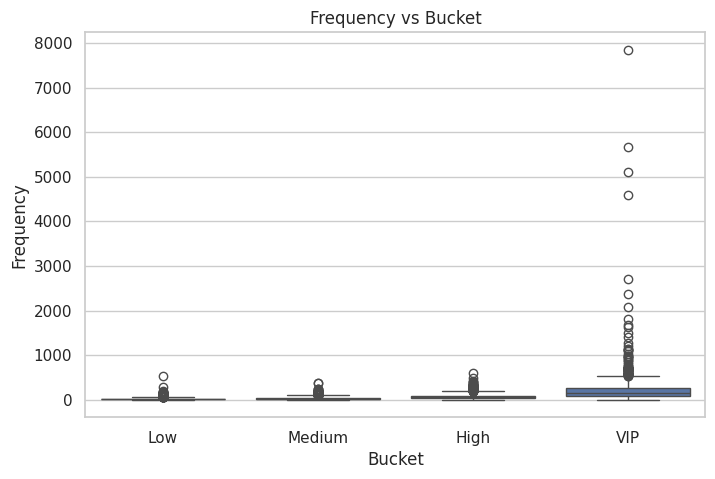

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Bucket", y="Frequency", data=dataset)
plt.title("Frequency vs Bucket")
plt.show()


In [ ]:
#Model Training

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = dataset[["Recency","Frequency","Monetary","Tenure","Trend"]]
y = dataset["Bucket"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = RandomForestClassifier(n_estimators=100, class_weight="balanced")
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

In [ ]:
#Evaluation

from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.84      0.86      0.85       217
         Low       1.00      0.95      0.97       217
      Medium       0.88      0.89      0.89       217
         VIP       0.93      0.94      0.94       217

    accuracy                           0.91       868
   macro avg       0.91      0.91      0.91       868
weighted avg       0.91      0.91      0.91       868

[[187   0  16  14]
 [  1 206  10   0]
 [ 21   1 194   1]
 [ 13   0   0 204]]



The model achieves strong overall performance with a macro F1-score of 0.91, indicating balanced prediction across all customer segments.

The Low and VIP segments are predicted with high precision and recall, showing that extreme customer behaviors are well captured by the model.

However, there is noticeable confusion between High and Medium segments, suggesting that their behavioral patterns overlap and are less distinguishable using the current features.


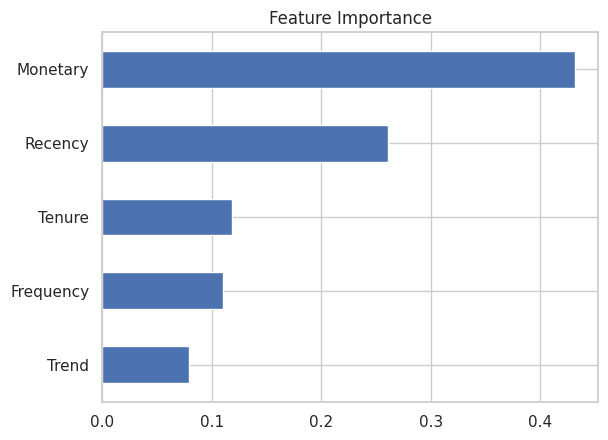

In [ ]:
#Feature Importance

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

1. Monetary is the most important feature, indicating that total spend strongly influences customer segmentation.

2. Recency also plays a key role, showing that recent activity impacts future value, with more recent customers being more likely to fall into higher-value segments.

3. Frequency has significant importance, as customers who purchase more often tend to contribute higher overall value and are more likely to belong to High or VIP segments.

4. Tenure shows moderate importance, suggesting that longer customer relationships contribute to stability and value, but are not as strong a predictor as spending behavior.

5. Trend has lower importance, indicating that short-term fluctuations in spending are less reliable for predicting long-term customer value.

In [ ]:
import joblib

joblib.dump(model, "rf_model.pkl")

from google.colab import files
files.download("rf_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Prediction Function + Test

import pandas as pd

def predict_customer(input_data):
    features = pd.DataFrame([input_data])
    prediction = model.predict(features)
    return prediction[0]


# Example test
sample = {
    "Recency": 10,
    "Frequency": 50,
    "Monetary": 5000,
    "Tenure": 200,
    "Trend": 20
}

print("Predicted Bucket:", predict_customer(sample))

Predicted Bucket: VIP
